<a href="https://colab.research.google.com/github/NguyenQuan297/CS4410_Assignment_Troy_2026Spring/blob/main/HomeWork3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ex 15.8 — Classification with the Iris Dataset: Hyperparameter Tuning (KNN)

This notebook:
1. Loads the **Iris** dataset from `sklearn.datasets`.
2. Uses **10-fold cross-validation** via `cross_val_score(cv=10)` to evaluate KNN for **k = 1..30**.
3. Plots:
   - **Value of K for KNN** vs **Cross-Validated Accuracy** (full range)
   - A **zoomed** plot around the best k
4. Uses **GridSearchCV** to confirm the best `n_neighbors`.


In [15]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# 1) Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (150, 4)
y shape: (150,)


In [16]:
# 2) Hyperparameter tuning with 10-fold cross-validation (cv=10)
k_range = range(1, 31)   # k = 1..30
mean_scores = []
std_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10)  # 10-fold CV
    mean_scores.append(scores.mean())
    std_scores.append(scores.std())

mean_scores = np.array(mean_scores)
std_scores = np.array(std_scores)

best_idx = int(np.argmax(mean_scores))
best_k = list(k_range)[best_idx]
best_score = mean_scores[best_idx]

print(f"Best k from cross_val_score(cv=10): k={best_k}, mean accuracy={best_score:.4f}")


Best k from cross_val_score(cv=10): k=13, mean accuracy=0.9800


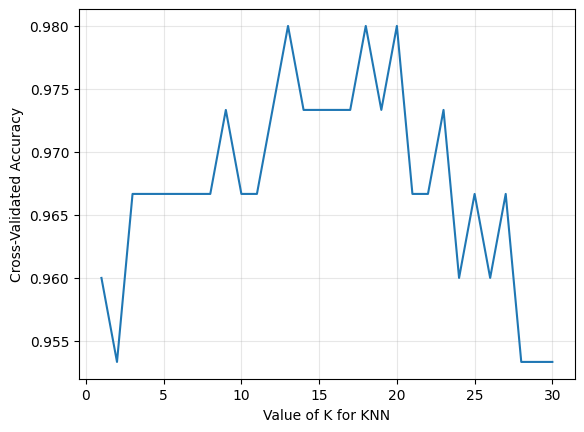

In [17]:
# 3) Plot: Value of K for KNN vs Cross-Validated Accuracy (full range)
plt.figure()
plt.plot(list(k_range), mean_scores)
plt.xlabel("Value of K for KNN")
plt.ylabel("Cross-Validated Accuracy")
plt.xticks(np.arange(0,31,5))
plt.grid(True, alpha=0.3)
plt.show()


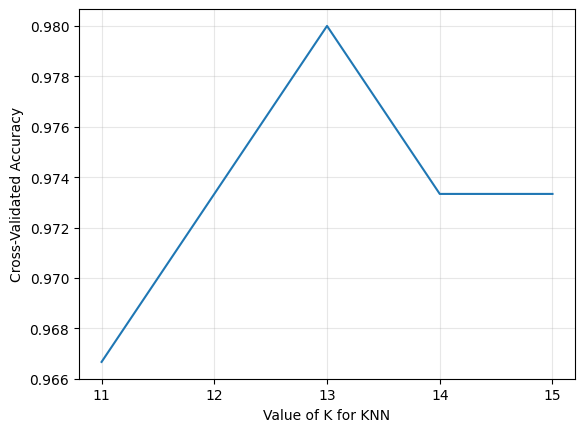

In [18]:
#3) Zoomed plot around the best k (example: best_k ± 2)
zoom_min = max(1, best_k - 2)
zoom_max = min(30, best_k + 2)

zoom_ks = np.arange(zoom_min, zoom_max + 1)
zoom_scores = mean_scores[zoom_min - 1: zoom_max]

plt.figure()
plt.plot(zoom_ks, zoom_scores)
plt.xlabel("Value of K for KNN")
plt.ylabel("Cross-Validated Accuracy")
plt.xticks(list(zoom_ks))
plt.grid(True, alpha=0.3)
plt.show()


In [19]:
# 4) GridSearchCV to confirm the best k
param_grid = {"n_neighbors": list(k_range)}
knn = KNeighborsClassifier()

grid = GridSearchCV(knn, param_grid=param_grid, cv=10)
grid.fit(X, y)

print("Best params from GridSearchCV:", grid.best_params_)
print(f"Best CV accuracy from GridSearchCV: {grid.best_score_:.4f}")


Best params from GridSearchCV: {'n_neighbors': 13}
Best CV accuracy from GridSearchCV: 0.9800
